<h1>Neural Networks</h1>

[<img src="./pics/Wiki_neural_network.png" width="250"/>](./pics/Wiki_neural_network.png)
*(image source: Wikipedia)*

What are they? 
- functions with a simple, yet arbitrarily complex, structure
- universal approximators: fine-tuning the parameters can approximate any function

Basic unit: **the perceptron**

[<img src="./pics/Perceptron.png" width="250"/>](./pics/Perceptron.png)
*(image source: https://pub.aimind.so/perceptron-101-the-building-blocks-of-a-neural-network-496f6b9b3826)*

**Key ideas:**
- we have $x_1,...,x_n$ inputs, which are "fed" into the next node
- on each connection we have weights $w_1,...,w_n$
- the scalar product $x \cdot w = \sum x_i w_i$ is computed
- a **bias** is applied: $x \cdot w + b$
- an **activation function** $\sigma$ is applied: sigmoid, ReLU, etc:
- **final output**: $\sigma(x \cdot w + b)$

The **activation function** mimicks the role of neuron activations in the brain. Examples:
- ReLU: takes the positive part of $x$: $x$ if $x\geq 0$, zero otherwise. Drawback: discontinuous derivative at $0$, flat region for $x<0$
- Sigmoid: $x \mapsto \frac{1}{1+e^{-x}}$. A smooth function going from $0$ (at $-\infty$) to $1$ (at $+\infty$). Drawback: almost flat regions, overflow, underflow in the exponential function.

**Neural network with fully connected layers**

- $x \in \Bbb{R}^N$ is an input with $N$ real parameters
- **Layer 1**: $N_1$ perceptrons. The $N$ previous inputs are fed into the $N_1$ perceptrons giving $N_1$ outputs
- **Layer 2**: $N_2$ perceptrons. The $N_1$ outputs from the previous layer are fed into the $N_2$ perceptrons giving $N_2$ outputs
- ...
- **final output**: $y \in \Bbb{R}^M$

Intermediary layers of the network are often called **hidden layers**. Their number and structure are chosen by the user. Important property: 
- The number of outputs for the layer $k-1$ must coincide with the number of inputs for the layer $k$
- Failing to do this will cause a *shape* error: mathematical analogue - multiplying matrices requires compatibility of dimensions

<h2>Number of parameters for a given Fully Connected Layer</h2>

Consider a fully connected layer with $N_1$ inputs and $N_2$ perceptrons.
- each connection between inputs and perceptrons has a weight: $N_1 \times N_2$ weights
- each perceptron has a bias: $N_2$ biases

**Matrix form for the forward pass**:
- $x \in \Bbb{R}^{N_1}$ is the input
- $w \in \Bbb{R}^{N_2 \times N_1}$ is the weight matrix: coefficients of each perceptron on lines
- $b \in \Bbb{R}^{N_2}$ is the vector containing the $N_2$ biases
- $\sigma$ is the non-linear activation function
- **Output of the layer**: $\sigma(W\cdot x + b)$

**Key observation**: if non-linear activation functions are not used then the Neural Network is simply a composition of affine functions, yielding an affine function. Non-linear processes **require** the usage of non-linear activation functions!

**Simple Neural Network Test**

Let us start by learning a one dimensional object: a function $f: [-1,1] \to \Bbb{R}$.

We need to:
- acquire data points: $(x_i, f(x_i))$ representing the known values (or measurements) for the function $f$
- define the network structure: number and structure of **hidden layers**, choose the **activation function**
- find a way to **tune the weights** for the hidden layers such that the network approximates $f$ even at **points not in the dataset**


Let us approximate $f:[-1,1] \to \Bbb{R}$, $f(x) = x^2$.

**Generate data:** in this case we generate a bunch of points $x_i \in [-1,1]$ as inputs. The outputs will be $x_i^2$ for each $i$.

The data looks like: 
$$ (x_1,x_1^2),(x_2,x_2^2),...$$

**Note:** In general, data generation and labeling is not that easy.

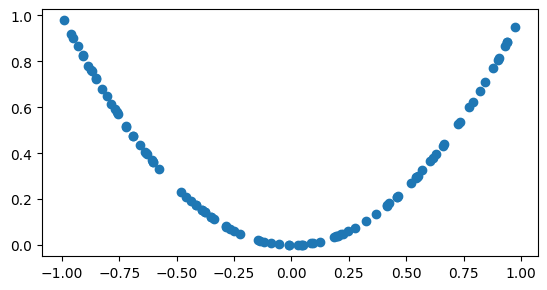

In [12]:
# use numpy to work with arrays in Python
# advantage vs list/arrays: we can do linear algebra straight away using vectorized operations

import numpy as np
import matplotlib.pyplot as plt # library allowing to visualize data

# setting the seed for random number generator produces reproducible results
np.random.seed(seed=42)

# set the number of sample points
nSamples = 100

# random numbers between 0 and 1
input = np.random.rand(nSamples)

# transform into random numbers between [-1,1]
Xnp = 2*input-1

# compute output data

ynp = Xnp**2
#y = np.sin(np.pi*X)   # in case you decide to try some other functions

# plotting the data: visualizations are important
plt.figure()
plt.scatter(Xnp,ynp)
plt.axis("scaled")
plt.show()

Add an extra dimension to the input so that PyTorch doesn't try to feed the whole input database into the model, but one element at a time.

In [41]:
# Import the PyTorch library
# This allows us to create and work with neural networks in Python
import torch

# Main tools in Pytorch are tensors: arrays of arbitrary dimension
X = torch.from_numpy(Xnp).type(torch.float)
X = X.unsqueeze(dim=1)
print(X)
y = torch.from_numpy(ynp).type(torch.float)

# View the first five samples
X[:5], y[:5]
X.shape

tensor([[-0.2509],
        [ 0.9014],
        [ 0.4640],
        [ 0.1973],
        [-0.6880],
        [-0.6880],
        [-0.8838],
        [ 0.7324],
        [ 0.2022],
        [ 0.4161],
        [-0.9588],
        [ 0.9398],
        [ 0.6649],
        [-0.5753],
        [-0.6364],
        [-0.6332],
        [-0.3915],
        [ 0.0495],
        [-0.1361],
        [-0.4175],
        [ 0.2237],
        [-0.7210],
        [-0.4157],
        [-0.2673],
        [-0.0879],
        [ 0.5704],
        [-0.6007],
        [ 0.0285],
        [ 0.1848],
        [-0.9071],
        [ 0.2151],
        [-0.6590],
        [-0.8699],
        [ 0.8978],
        [ 0.9313],
        [ 0.6168],
        [-0.3908],
        [-0.8047],
        [ 0.3685],
        [-0.1197],
        [-0.7559],
        [-0.0096],
        [-0.9312],
        [ 0.8186],
        [-0.4824],
        [ 0.3250],
        [-0.3766],
        [ 0.0401],
        [ 0.0934],
        [-0.6303],
        [ 0.9392],
        [ 0.5503],
        [ 0.

torch.Size([100, 1])

If you have a given amount of data of the form $f(x_i) = y_i$ and you want to create a network to approximate the function $f$, you need to evaluate how your network behaves on inputs it hasn't seen before. 

Therefore it is recommended to take a percentage of the data (for example 20%) to keep for the testing phase and use the remaining 80% as the train data. This division can be done manually or using available functions, like in the cell below.

In [28]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

Having a NVIDIA graphics card can speed up computations in some cases. PyTorch allows to choose on which "device" to run the computations. For simple configurations with one gpu, we need to choose between "cpu" (default device) and "cuda". 

It is possible to write *device agnostic* code, in which the code will run on "cuda" if it is available, otherwise it will run on "cpu".

In the case you get an error of the type "Pytorch expects variables on the same device", check that your model and data are present to the same device.

In [3]:
!nvidia-smi

Thu Apr  9 00:43:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro T2000                   Off |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P8              2W /   60W |       6MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
# Standard PyTorch imports
import torch
from torch import nn

# sending a tensor to cuda (if available)
torch.zeros(1).cuda()

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
#device = "cpu"
device

'cuda'

A Neural Network can be constructed in PyTorch by extending the `nn.Module` class. 
- defining fully connected layers can be achieved using `nn.Linear(in_features = ..., out_features = ...)`
- each Neural Network needs a `forward` method defined: this shows how the information is evaluated. It can simply be a composition of functions or something more complex

In [75]:
# Build model with non-linear activation function



from torch import nn
class Model1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=1, out_features=100)
        self.layer_2 = nn.Linear(in_features=100, out_features=100)
        self.layer_3 = nn.Linear(in_features=100, out_features=1)
        self.nonl = nn.Sigmoid() # <- try to add in ReLU activation function

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.nonl(self.layer_2(self.nonl(self.layer_1(x)))))
       #return self.layer_3(self.layer_2(self.layer_1(x)))

# Create one instance of the model
# Run this cell again if you want to re-initialize the model
# Initial parameters of the model are chosen randomly: to have reproducible results we need to set the seed to a fixed number
model = Model1().to(device)
print(model)

Model1(
  (layer_1): Linear(in_features=1, out_features=100, bias=True)
  (layer_2): Linear(in_features=100, out_features=100, bias=True)
  (layer_3): Linear(in_features=100, out_features=1, bias=True)
  (nonl): Sigmoid()
)


In [76]:
# to view details about the model use "summary" from "torchinfo"
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
Model1                                   --
├─Linear: 1-1                            200
├─Linear: 1-2                            10,100
├─Linear: 1-3                            101
├─Sigmoid: 1-4                           --
Total params: 10,401
Trainable params: 10,401
Non-trainable params: 0

The next step is defining a "loss function". This is a function which PyTorch will minimize and should "force" the model to be come good at understanding the data. 

The `MSELoss`, Mean Squared Error Loss, is defined by
$$ MSELoss(Params) = \frac{1}{N} \sum_{i=1}^N (NN_Model(Params,x_i) - y_i)^2 $$

The optimization algorithm will "tune" the parameters `Params` such that the above function becomes as small as possible. In that case we will achieve the goal:
$$ NN_Model(Params,x_i) \approx y_i$$

Below you can see how to set up the loss function `loss_fn`. Multiple options exist, depending on the application. 

Also, it is necessary to choose an optimization algorithm. These are found in the `torch.optim` module. We must tell the algorithm which arguments to minimize, for example: `model.parameters()`. Most of the optimization algorithms are based on the Gradient Descent algorithm:

- Initialization: choose initial parameters $p_0$
- Perform a number of iterations (called epochs in ML): $x_{n+1}=x_n - \alpha \nabla loss\_fn(x_n)$
- $\alpha>0$ is the *descent step* or *learning rate*. It should not be too big (oscillations) nor too small (slow convergence). It is generally given as a parameter to the learning algorithm: `lr=...`

In [80]:
# Setup loss and optimizer 
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
TrainLoss = []
TestLoss = []

Now we are ready to train the model. 
- put the data on the same device
- at each iteration: compute the model on the train data
- apply the loss function to see how the model result agrees with the data
- PyTorch automatically computes the sensitivities (derivatives) with respect to all the parameters. This process is called **backpropagation** This allows the use of gradient based optimization algorithms.
- To evaluate the model on the *test data* we do not need to keep track of gradients (this is more expensive than just evaluating the model!). To evaluate without backpropagation, use the context `with torch.inference_mode()`.

Running the next cell without re-initializing the model will keep optimizing the same model parameters. If you want to **restart**, run again the cell where the model is defined!

Epoch: 0 | Loss: 0.09123 | Test Loss: 0.07809
Epoch: 100 | Loss: 0.08364 | Test Loss: 0.07061
Epoch: 200 | Loss: 0.03791 | Test Loss: 0.03112
Epoch: 300 | Loss: 0.00015 | Test Loss: 0.00021
Epoch: 400 | Loss: 0.00014 | Test Loss: 0.00015
Epoch: 500 | Loss: 0.00014 | Test Loss: 0.00014
Epoch: 600 | Loss: 0.00018 | Test Loss: 0.00021
Epoch: 700 | Loss: 0.00012 | Test Loss: 0.00013
Epoch: 800 | Loss: 0.00017 | Test Loss: 0.00022
Epoch: 900 | Loss: 0.00012 | Test Loss: 0.00012


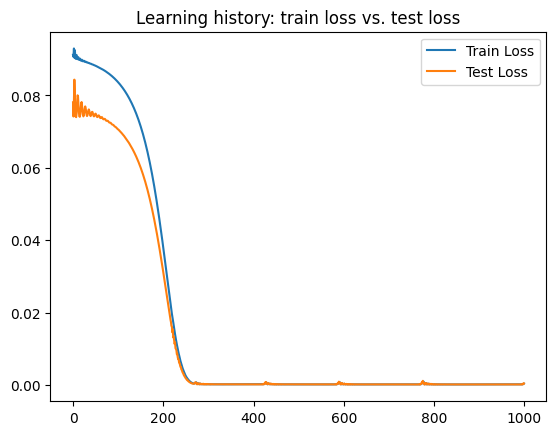

In [81]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)



for epoch in range(epochs):
    # 1. Forward pass
    model.train()
    
    y_logits = model(X_train).flatten()
    
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # 
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model(X_test).flatten()
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      
    TrainLoss.append(loss.cpu().detach().numpy())
    TestLoss.append(test_loss.cpu().numpy())
    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

plt.figure()

plt.plot(TrainLoss,label="Train Loss")
plt.plot(TestLoss,label="Test Loss")
plt.title("Learning history: train loss vs. test loss")
plt.legend()
plt.show()


When plotting the *train loss* and *test loss* you should pay attention to the following:
- **underfitting**: if you observe the two curves are decreasing a lot towards the end of the training, probably the training should be continued for more iterations. We can "do better".
- **overfitting**: it is natural that the *train loss* is decreasing. This is what the algorithm minimizes. If you observe that the *train loss* decreases while the *test loss* begins to increase then the model "learns the data by heart" and is not "able to generalize correctly". Stop and review the following:

* Use more data
* Simplify the model: complex models (many neurons/layers) have big learning capacity. If you don't have enough data, don't choose an overly complicated model

tensor([[0.7376],
        [0.6129],
        [0.2885],
        [0.0849],
        [0.2209]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([0.7619, 0.6236, 0.2965, 0.1057, 0.2327], device='cuda:0')


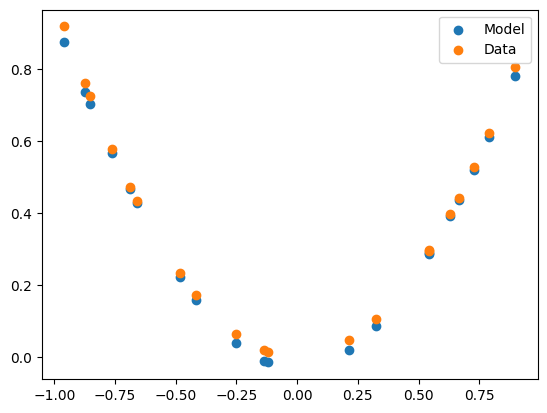

In [82]:
# Visualize test data against predictions give by the model
Res = model(X_test)
print(Res[:5])
print(y_test[:5])

plt.figure()
plt.scatter(X_test.cpu().numpy(),Res.detach().cpu().numpy(),label="Model")
plt.scatter(X_test.cpu().numpy(),y_test.cpu().numpy(),label="Data")
plt.legend()
plt.show()

**What happens if we test with inputs "far away" from the given training data?**

As expected, the model cannot predict what it hasn't seen. In this case, data was taken from $[-1,1]$. Looking outside this interval will not provide useful results. You can change the non-linear activation function and notice that outside $[-1,1]$ we see the shape of the activation function. 

If in this simple case, learning to generalize a 1D function is impossible outside the given data, imagine what happens in more complex situations. This is one of the main drawbacks of using neural networks to learn: having general enough data is important, outliers can cause problems.

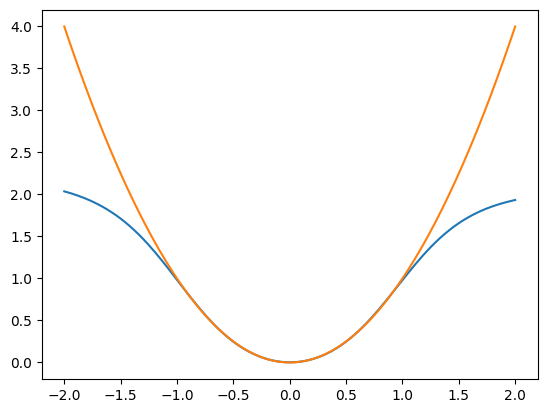

In [55]:
# What happens if we test outside the learning interval? 

newx = np.linspace(-2,2,200)
newx = torch.from_numpy(newx).type(torch.float).to(device)
newx = newx.unsqueeze(dim=1)


newy = model(newx)

plt.figure()
plt.plot(newx.cpu().detach().numpy(),newy.cpu().detach().numpy())
plt.plot(newx.cpu().detach().numpy(),newx.cpu().detach().numpy()**2)
#plt.plot(newx.cpu().detach().numpy(),np.sin(np.pi*newx.cpu().detach().numpy()))

plt.show()




**Exercises**

1. Pick a different function and test how the learning algorithm approximates it inside and outside $[-1,1]$.
2. Change the activation function from `sigmoid` to `relu` and observe the difference outside $[-1,1]$.
3. Pick different parameters in the intermediary layers of the network. Pay attention to have compatible dimensions.
4. Change the optimization algorithm from `Adam` to `SGD`. What do you observe?
5. Change the size of the data: more points, fewer points, etc. 